In [52]:
# Import required libraries
import os
os.environ['KERAS_BACKEND'] = 'jax'  # Use JAX backend for Keras
from sklearn.metrics import auc

import pandas as pd
import numpy as np
import keras
from keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}")
print("✓ All libraries imported successfully!")


Keras version: 3.12.0
Keras backend: jax
✓ All libraries imported successfully!


In [30]:
# Load the PROPERLY preprocessed data
df_preprocessed = pd.read_csv('preprocessed_data_final.csv')
print(f"Preprocessed data loaded: {df_preprocessed.shape}")
print(f"\nColumns: {list(df_preprocessed.columns)}")

# Verify all numeric
print(f"\nData types:")
print(df_preprocessed.dtypes.value_counts())

# Check for object types
object_cols = df_preprocessed.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    print(f"\n⚠️ WARNING: Found non-numeric columns: {object_cols}")
else:
    print("\n✓ All columns are numeric!")

df_preprocessed.head()


Preprocessed data loaded: (100000, 33)

Columns: ['attack_type', 'target_system', 'data_compromised_GB', 'attack_duration_min', 'security_tools_used', 'user_role', 'attack_severity', 'response_time_min', 'mitigation_method', 'attacker_ip_oct_1', 'attacker_ip_oct_2', 'attacker_ip_oct_3', 'attacker_ip_oct_4', 'target_ip_oct_1', 'target_ip_oct_2', 'target_ip_oct_3', 'target_ip_oct_4', 'year', 'month', 'day', 'day_of_week', 'hour', 'minute', 'is_weekend', 'is_night', 'is_business_hours', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'target']

Data types:
int64      26
float64     7
Name: count, dtype: int64

✓ All columns are numeric!


,attack_type,target_system,data_compromised_GB,attack_duration_min,security_tools_used,user_role,attack_severity,response_time_min,mitigation_method,attacker_ip_oct_1,...,is_weekend,is_night,is_business_hours,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,target
0,1,2,59.42,259,5,1,4,79,0,7,...,0,0,1,-0.866025,-0.500000,0.781831,0.62349,-1.0,-1.836970e-16,1
1,1,2,41.52,166,3,0,6,83,4,75,...,0,0,1,-0.965926,-0.258819,0.781831,0.62349,-1.0,-1.836970e-16,1
2,3,6,75.79,93,3,0,8,35,4,9,...,0,0,1,-0.965926,-0.258819,0.781831,0.62349,-1.0,-1.836970e-16,0
3,5,0,37.39,126,5,1,3,36,0,222,...,0,0,1,-0.965926,-0.258819,0.781831,0.62349,-1.0,-1.836970e-16,0
4,5,1,56.00,20,6,0,7,117,0,137,...,0,0,1,-0.965926,-0.258819,0.781831,0.62349,-1.0,-1.836970e-16,0


In [31]:
# Define target variable and features
print("Defining features and target...")

# Target is the 'attack_type' column (8 different attack types)
y = df_preprocessed['attack_type']

# Remap attack_type to start from 0 (required for sparse_categorical_crossentropy)
unique_types = np.sort(y.unique())
print(f"Original attack types: {unique_types}")

# Create mapping: original value -> 0-7
type_mapping = {old_val: new_val for new_val, old_val in enumerate(unique_types)}
y = y.map(type_mapping)

print(f"Remapped attack types: {np.sort(y.unique())}")

X = df_preprocessed.drop(columns=['attack_type', 'target'])


Defining features and target...
Original attack types: [0 1 2 3 4 5 6 7]
Remapped attack types: [0 1 2 3 4 5 6 7]


In [32]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")

# Convert to numpy arrays with proper dtype
X_train = X_train.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

# Check for any non-numeric values
print(f"\nX_train dtype: {X_train.dtype}")
print(f"X_test dtype: {X_test.dtype}")
print(f"y_train dtype: {y_train.dtype}")
print(f"y_test dtype: {y_test.dtype}")

print("\n✓ Data prepared for training!")


Training set: (80000, 31)
Testing set: (20000, 31)

Training target distribution:
attack_type
0    10084
2    10046
7    10044
5     9999
3     9975
6     9970
4     9953
1     9929
Name: count, dtype: int64

Testing target distribution:
attack_type
0    2521
7    2511
2    2511
5    2500
3    2494
6    2493
4    2488
1    2482
Name: count, dtype: int64

X_train dtype: float32
X_test dtype: float32
y_train dtype: float32
y_test dtype: float32

✓ Data prepared for training!


In [33]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")

# Convert to numpy arrays with proper dtype
X_train = X_train.values.astype(np.float32)
X_test = X_test.values.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

# Check for any non-numeric values
print(f"\nX_train dtype: {X_train.dtype}")
print(f"X_test dtype: {X_test.dtype}")
print(f"y_train dtype: {y_train.dtype}")
print(f"y_test dtype: {y_test.dtype}")

# Check for NaN or Inf values
print(f"\nX_train has NaN: {np.isnan(X_train).any()}")
print(f"X_train has Inf: {np.isinf(X_train).any()}")

print("\n✓ Data prepared for training!")


Training set: (80000, 31)
Testing set: (20000, 31)

Training target distribution:
attack_type
0    10084
2    10046
7    10044
5     9999
3     9975
6     9970
4     9953
1     9929
Name: count, dtype: int64

Testing target distribution:
attack_type
0    2521
7    2511
2    2511
5    2500
3    2494
6    2493
4    2488
1    2482
Name: count, dtype: int64

X_train dtype: float32
X_test dtype: float32
y_train dtype: float32
y_test dtype: float32

X_train has NaN: False
X_train has Inf: False

✓ Data prepared for training!


In [34]:
# Scale the features properly
from sklearn.preprocessing import StandardScaler

print("Scaling features...")
print(f"Before scaling - X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]")

# Create and fit scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"After scaling - X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"After scaling - X_train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")

# Convert back to float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("✓ Features scaled successfully!")


Scaling features...
Before scaling - X_train range: [-1.0000, 2024.0000]
After scaling - X_train range: [-1.7383, 1.7283]
After scaling - X_train mean: -0.0000, std: 1.0000
✓ Features scaled successfully!


In [35]:
# Deep Data Analysis
print("="*80)
print("DEEP DATA ANALYSIS")
print("="*80)

# 1. Check target distribution
print("\n1. Target Distribution:")
print(f"   Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"   Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

# 2. Check if features have any variance
print("\n2. Feature Variance Check:")
feature_std = X_train.std(axis=0)
zero_variance = (feature_std == 0).sum()
print(f"   Features with zero variance: {zero_variance}")
print(f"   Features with variance: {len(feature_std) - zero_variance}")

# 3. Check correlation with target
print("\n3. Feature-Target Correlation (Top 10):")
correlations = []
for i in range(X_train.shape[1]):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    correlations.append((i, abs(corr)))

correlations.sort(key=lambda x: x[1], reverse=True)
for i, (feat_idx, corr) in enumerate(correlations[:10]):
    print(f"   Feature {feat_idx}: {corr:.4f}")

max_corr = correlations[0][1]
if max_corr < 0.1:
    print("\n   ⚠️ WARNING: Very weak correlations! Features may not be predictive.")
elif max_corr < 0.3:
    print("\n   ⚠️ Weak correlations. Model may struggle.")
else:
    print("\n   ✓ Good correlations found!")

# 4. Check if data is actually random
print("\n4. Baseline Prediction:")
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = dummy.score(X_test, y_test)
print(f"   Random baseline accuracy: {dummy_acc:.4f}")
print(f"   Your model needs to beat: {dummy_acc:.4f}")

print("\n" + "="*80)


DEEP DATA ANALYSIS

1. Target Distribution:
   Class 0: 10084 (12.61%)
   Class 1: 9929 (12.41%)

2. Feature Variance Check:
   Features with zero variance: 0
   Features with variance: 31

3. Feature-Target Correlation (Top 10):
   Feature 16: 0.0094
   Feature 8: 0.0073
   Feature 30: 0.0066
   Feature 21: 0.0058
   Feature 17: 0.0055
   Feature 28: 0.0051
   Feature 1: 0.0041
   Feature 29: 0.0035
   Feature 2: 0.0035
   Feature 22: 0.0032

   ⚠️ WARNING: Very weak correlations! Features may not be predictive.

4. Baseline Prediction:
   Random baseline accuracy: 0.1260
   Your model needs to beat: 0.1260



In [36]:
#Model
print("Building Neural Network Model...")
print("="*60)

model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(8, activation='softmax')  
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Changed for multi-class classification
    metrics=['accuracy']
)

model.summary()


Building Neural Network Model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,688 (6.59 KB)

 Trainable params: 1,688 (6.59 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Check if data is properly prepared
print("Data Diagnostics:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_train dtype: {X_train.dtype}")
print(f"y_train dtype: {y_train.dtype}")
print(f"\nX_train range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"y_train unique values: {np.unique(y_train)}")
print(f"y_train distribution: {np.bincount(y_train.astype(int).flatten())}")

# Check for issues
if np.isnan(X_train).any():
    print("⚠️ WARNING: X_train contains NaN values!")
if np.isinf(X_train).any():
    print("⚠️ WARNING: X_train contains Inf values!")
if len(np.unique(y_train)) != 2:
    print("⚠️ WARNING: Target should have exactly 2 classes!")


Data Diagnostics:
X_train shape: (80000, 31)
y_train shape: (80000,)
X_train dtype: float32
y_train dtype: float32

X_train range: [-1.7383, 1.7283]
y_train unique values: [0. 1. 2. 3. 4. 5. 6. 7.]
y_train distribution: [10084  9929 10046  9975  9953  9999  9970 10044]
⚠️ WARNING: Target should have exactly 2 classes!


In [38]:
# Train the model 
print("\nTraining the model...")
print("="*60)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.00001,
            verbose=1
        )
    ]
)

print("\n✓ Model training completed!")



Training the model...
Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - accuracy: 0.1232 - loss: 2.1168 - val_accuracy: 0.1234 - val_loss: 2.0803 - learning_rate: 0.0010
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - accuracy: 0.1257 - loss: 2.0807 - val_accuracy: 0.1295 - val_loss: 2.0796 - learning_rate: 0.0010
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.1261 - loss: 2.0798 - val_accuracy: 0.1231 - val_loss: 2.0795 - learning_rate: 0.0010
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.1283 - loss: 2.0796 - val_accuracy: 0.1289 - val_loss: 2.0794 - learning_rate: 0.0010
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.1268 - loss: 2.0794 - val_accuracy: 0.1244 - val_loss: 2.0794 - learning_rate: 0.0010
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.1226 - loss: 2.0795 - val_accuracy: 0.1235 - val_loss: 2.0794 - learning_rate: 0.0010
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━

In [39]:
# Evaluate the model
print("\n" + "="*80)
print("MODEL EVALUATION")
print("="*80)

# Training evaluation
train_results = model.evaluate(X_train, y_train, verbose=0)
train_loss = train_results[0]
train_accuracy = train_results[1]

print(f"\nTraining Metrics:")
print(f"  Loss: {train_loss:.4f}")
print(f"  Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Testing evaluation
test_results = model.evaluate(X_test, y_test, verbose=0)
test_loss = test_results[0]
test_accuracy = test_results[1]

print(f"\nTesting Metrics:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



MODEL EVALUATION

Training Metrics:
  Loss: 2.0791
  Accuracy: 0.1278 (12.78%)

Testing Metrics:
  Loss: 2.0794
  Accuracy: 0.1253 (12.53%)


In [40]:
# Make predictions
print("Making predictions...")

y_pred_train_proba = model.predict(X_train, verbose=0)
y_pred_test_proba = model.predict(X_test, verbose=0)

# For multi-class classification, use argmax to get predicted class
y_pred_train = np.argmax(y_pred_train_proba, axis=1)
y_pred_test = np.argmax(y_pred_test_proba, axis=1)

# Calculate ROC-AUC for multi-class classification
train_roc_auc = roc_auc_score(y_train, y_pred_train_proba, multi_class='ovr', average='weighted')
test_roc_auc = roc_auc_score(y_test, y_pred_test_proba, multi_class='ovr', average='weighted')

print(f"\nTraining ROC-AUC: {train_roc_auc:.4f}")
print(f"Testing ROC-AUC: {test_roc_auc:.4f}")

print("\n" + "="*80)
print("CLASSIFICATION REPORT (Test Set)")
print("="*80)
print(classification_report(y_test, y_pred_test))


Making predictions...

Training ROC-AUC: 0.5066
Testing ROC-AUC: 0.4996

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

         0.0       0.13      0.89      0.22      2521
         1.0       0.10      0.00      0.01      2482
         2.0       0.15      0.01      0.01      2511
         3.0       0.13      0.08      0.10      2494
         4.0       0.21      0.00      0.00      2488
         5.0       0.09      0.01      0.02      2500
         6.0       0.10      0.00      0.01      2493
         7.0       1.00      0.00      0.00      2511

    accuracy                           0.13     20000
   macro avg       0.24      0.12      0.05     20000
weighted avg       0.24      0.13      0.05     20000




PER-CLASS ACCURACY

Accuracy for each attack type:
--------------------------------------------------
Class 0: 0.8909 (2246/2521 correct)
Class 1: 0.0040 (10/2482 correct)
Class 2: 0.0068 (17/2511 correct)
Class 3: 0.0794 (198/2494 correct)
Class 4: 0.0024 (6/2488 correct)
Class 5: 0.0088 (22/2500 correct)
Class 6: 0.0028 (7/2493 correct)
Class 7: 0.0004 (1/2511 correct)
--------------------------------------------------
Overall Accuracy: 0.1244

CONFUSION MATRIX


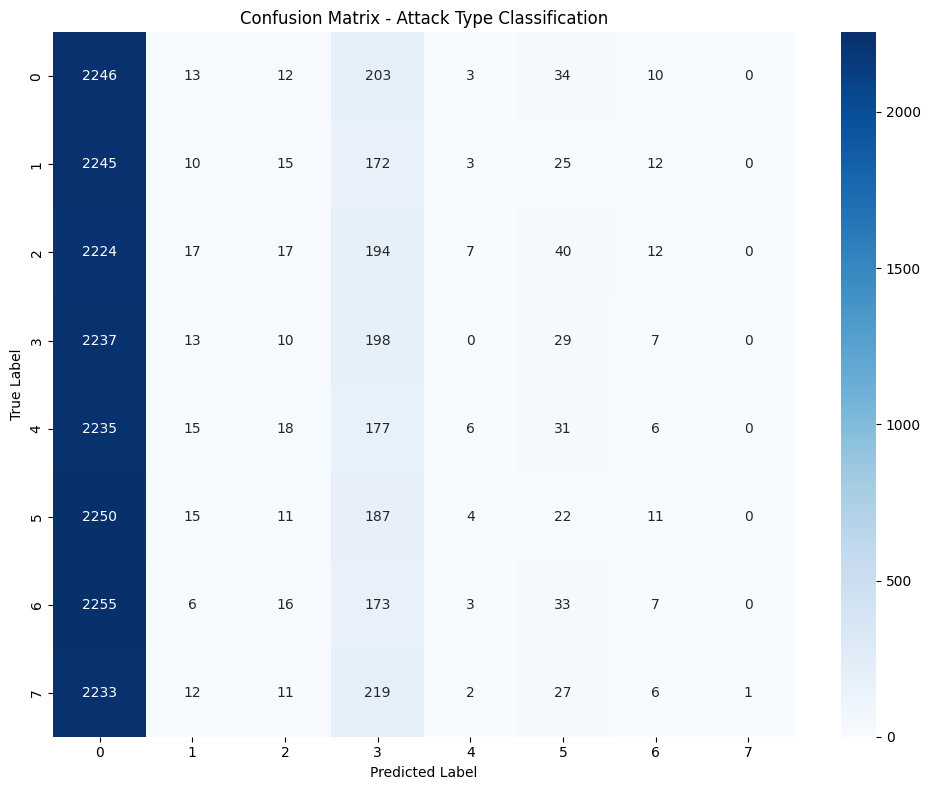


Most Common Misclassifications:
--------------------------------------------------
Class 6 misclassified as Class 0: 2255 times
Class 5 misclassified as Class 0: 2250 times
Class 1 misclassified as Class 0: 2245 times
Class 3 misclassified as Class 0: 2237 times
Class 4 misclassified as Class 0: 2235 times


In [41]:
# Calculate per-class accuracy
print("\n" + "="*80)
print("PER-CLASS ACCURACY")
print("="*80)

from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Get the original attack type names if available
# If you have the mapping from earlier, use it. Otherwise, just use class numbers
print("\nAccuracy for each attack type:")
print("-" * 50)

for class_idx in range(len(per_class_accuracy)):
    accuracy = per_class_accuracy[class_idx]
    total_samples = cm.sum(axis=1)[class_idx]
    correct_predictions = cm.diagonal()[class_idx]
    
    print(f"Class {class_idx}: {accuracy:.4f} ({correct_predictions:.0f}/{total_samples:.0f} correct)")

print("-" * 50)
print(f"Overall Accuracy: {np.mean(per_class_accuracy):.4f}")

# Visualize the confusion matrix
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix - Attack Type Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Show which classes are most confused with each other
print("\nMost Common Misclassifications:")
print("-" * 50)

# Find top 5 misclassifications
misclassifications = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            misclassifications.append((i, j, cm[i][j]))

# Sort by count
misclassifications.sort(key=lambda x: x[2], reverse=True)

for true_class, pred_class, count in misclassifications[:5]:
    print(f"Class {true_class} misclassified as Class {pred_class}: {count} times")


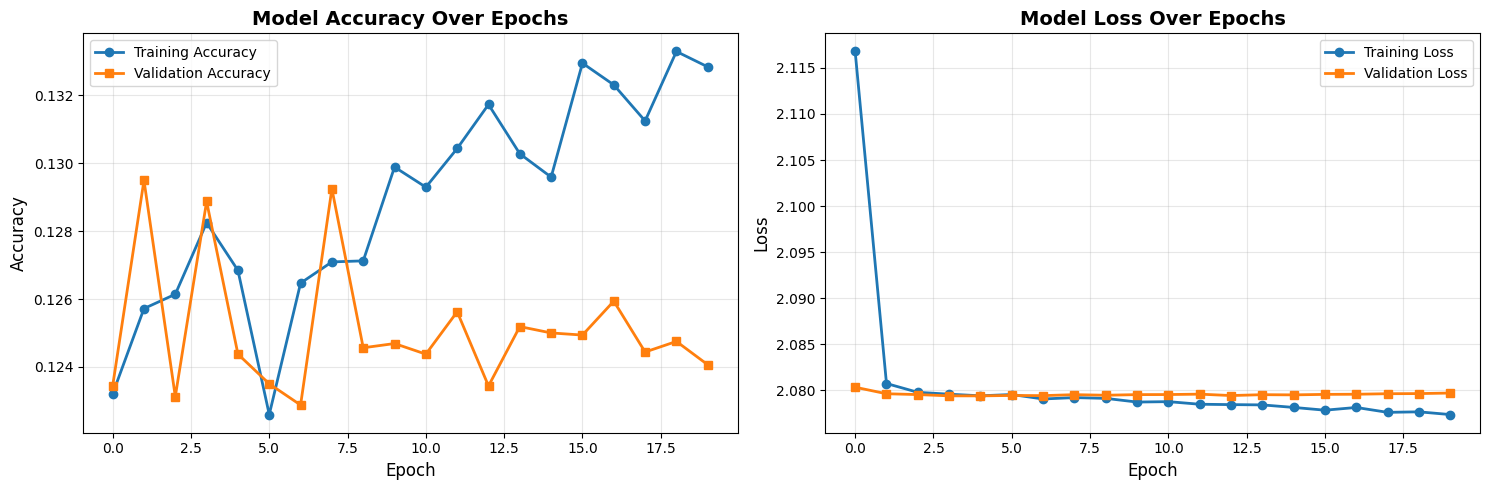

In [42]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


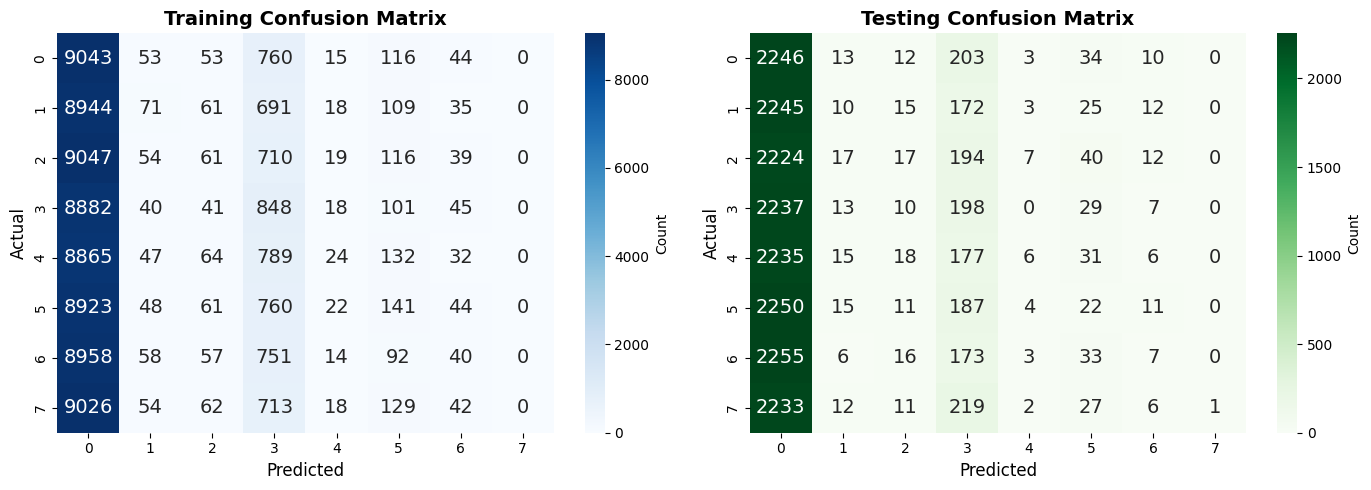


Training Confusion Matrix:
[[9043   53   53  760   15  116   44    0]
 [8944   71   61  691   18  109   35    0]
 [9047   54   61  710   19  116   39    0]
 [8882   40   41  848   18  101   45    0]
 [8865   47   64  789   24  132   32    0]
 [8923   48   61  760   22  141   44    0]
 [8958   58   57  751   14   92   40    0]
 [9026   54   62  713   18  129   42    0]]

True Negatives: 9043, False Positives: 53
False Negatives: 8944, True Positives: 71


Testing Confusion Matrix:
[[2246   13   12  203    3   34   10    0]
 [2245   10   15  172    3   25   12    0]
 [2224   17   17  194    7   40   12    0]
 [2237   13   10  198    0   29    7    0]
 [2235   15   18  177    6   31    6    0]
 [2250   15   11  187    4   22   11    0]
 [2255    6   16  173    3   33    7    0]
 [2233   12   11  219    2   27    6    1]]

True Negatives: 2246, False Positives: 13
False Negatives: 2245, True Positives: 10


In [43]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training Confusion Matrix
cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[0].set_title('Training Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Testing Confusion Matrix
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[1].set_title('Testing Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

# Print confusion matrix details
print("\nTraining Confusion Matrix:")
print(cm_train)
print(f"\nTrue Negatives: {cm_train[0,0]}, False Positives: {cm_train[0,1]}")
print(f"False Negatives: {cm_train[1,0]}, True Positives: {cm_train[1,1]}")

print("\n\nTesting Confusion Matrix:")
print(cm_test)
print(f"\nTrue Negatives: {cm_test[0,0]}, False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}, True Positives: {cm_test[1,1]}")


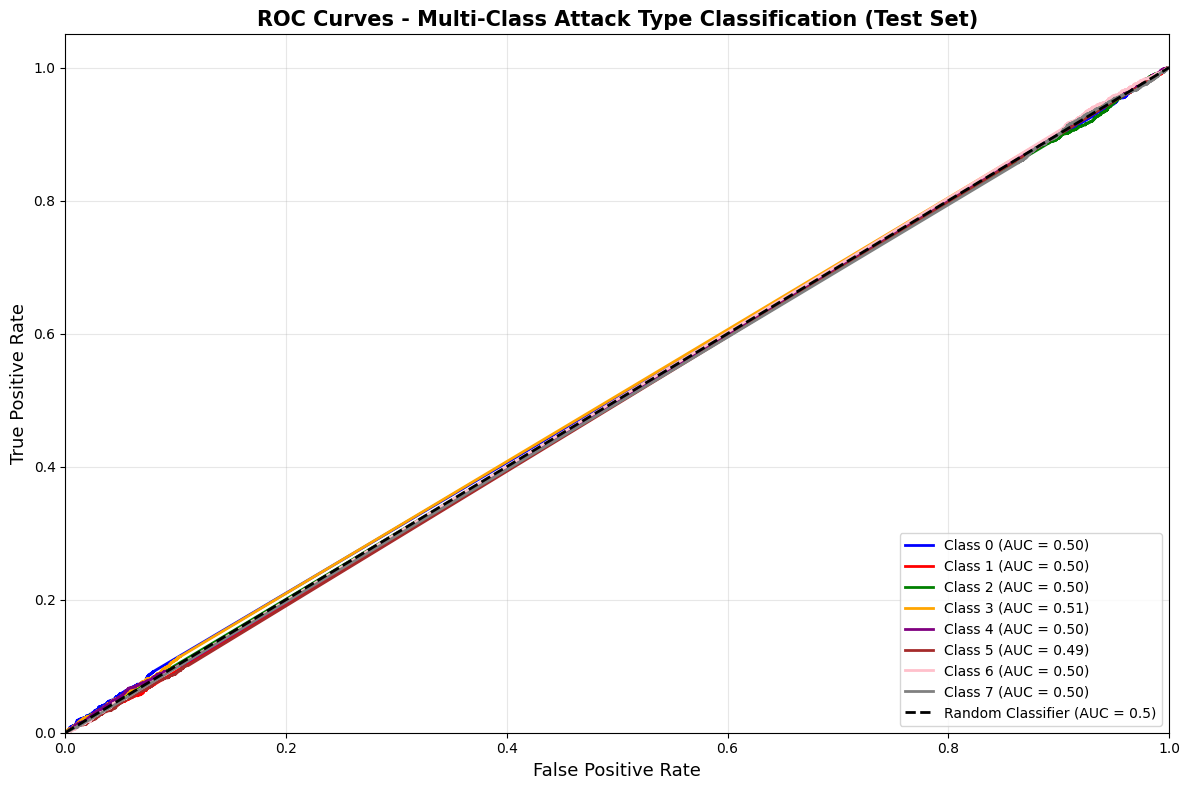


ROC-AUC SCORES PER CLASS

Test Set:
Class 0: 0.5039
Class 1: 0.4971
Class 2: 0.4986
Class 3: 0.5061
Class 4: 0.4994
Class 5: 0.4946
Class 6: 0.5013
Class 7: 0.4961

Macro Average: 0.4996
Weighted Average: 0.4996


In [53]:
# ROC Curve for Multi-Class Classification (One-vs-Rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc

from itertools import cycle

# Binarize the labels for multi-class ROC
y_train_bin = label_binarize(y_train, classes=range(8))
y_test_bin = label_binarize(y_test, classes=range(8))

# Compute ROC curve and ROC area for each class
fpr_train = dict()
tpr_train = dict()
roc_auc_train = dict()

fpr_test = dict()
tpr_test = dict()
roc_auc_test = dict()

for i in range(8):
    fpr_train[i], tpr_train[i], _ = roc_curve(y_train_bin[:, i], y_pred_train_proba[:, i])
    roc_auc_train[i] = auc(fpr_train[i], tpr_train[i])
    
    fpr_test[i], tpr_test[i], _ = roc_curve(y_test_bin[:, i], y_pred_test_proba[:, i])
    roc_auc_test[i] = auc(fpr_test[i], tpr_test[i])

# Plot ROC curves for test set
plt.figure(figsize=(12, 8))

colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray'])
for i, color in zip(range(8), colors):
    plt.plot(fpr_test[i], tpr_test[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc_test[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curves - Multi-Class Attack Type Classification (Test Set)', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print average AUC scores
print("\n" + "="*80)
print("ROC-AUC SCORES PER CLASS")
print("="*80)
print("\nTest Set:")
for i in range(8):
    print(f"Class {i}: {roc_auc_test[i]:.4f}")
print(f"\nMacro Average: {np.mean([roc_auc_test[i] for i in range(8)]):.4f}")
print(f"Weighted Average: {test_roc_auc:.4f}")


In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Training metrics - using 'weighted' average for multi-class
train_precision = precision_score(y_train, y_pred_train, average='weighted')
train_recall = recall_score(y_train, y_pred_train, average='weighted')
train_f1 = f1_score(y_train, y_pred_train, average='weighted')

# Testing metrics - using 'weighted' average for multi-class
test_precision = precision_score(y_test, y_pred_test, average='weighted')
test_recall = recall_score(y_test, y_pred_test, average='weighted')
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

print("\n" + "="*80)
print("ADDITIONAL METRICS")
print("="*80)

print("\nTraining Set:")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

print("\nTesting Set:")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Per-class metrics
print("\n" + "="*80)
print("PER-CLASS METRICS (Test Set)")
print("="*80)

# Calculate per-class precision, recall, and f1
per_class_precision = precision_score(y_test, y_pred_test, average=None)
per_class_recall = recall_score(y_test, y_pred_test, average=None)
per_class_f1 = f1_score(y_test, y_pred_test, average=None)

print("\n{:<10} {:<12} {:<12} {:<12}".format("Class", "Precision", "Recall", "F1-Score"))
print("-" * 50)
for i in range(8):
    print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f}".format(
        f"Class {i}", 
        per_class_precision[i], 
        per_class_recall[i], 
        per_class_f1[i]
    ))



ADDITIONAL METRICS

Training Set:
  Precision: 0.1254
  Recall:    0.1278
  F1-Score:  0.0490

Testing Set:
  Precision: 0.2396
  Recall:    0.1253
  F1-Score:  0.0460

PER-CLASS METRICS (Test Set)

Class      Precision    Recall       F1-Score    
--------------------------------------------------
Class 0    0.1253       0.8909       0.2197      
Class 1    0.0990       0.0040       0.0077      
Class 2    0.1545       0.0068       0.0130      
Class 3    0.1300       0.0794       0.0986      
Class 4    0.2143       0.0024       0.0048      
Class 5    0.0913       0.0088       0.0161      
Class 6    0.0986       0.0028       0.0055      
Class 7    1.0000       0.0004       0.0008      


In [49]:
# Model Architecture Summary
print("="*80)
print("MODEL ARCHITECTURE SUMMARY")
print("="*80)
print("\nLogistic Regression Based Neural Network")
print("-" * 80)
print("Layer 1: 32 neurons  → Sigmoid Activation")
print("Layer 2: 16 neurons  → Sigmoid Activation")
print("Layer 3: 8 neurons   → Sigmoid Activation")
print("Output:  1 neuron    → Sigmoid Activation (Binary Classification)")
print("-" * 80)
print(f"\nTotal Trainable Parameters: {model.count_params():,}")
print(f"Input Features: {X_train.shape[1]}")
print(f"Training Samples: {X_train.shape[0]:,}")
print(f"Testing Samples: {X_test.shape[0]:,}")
print(f"Total Epochs Trained: {len(history.history['loss'])}")
print("="*80)


MODEL ARCHITECTURE SUMMARY

Logistic Regression Based Neural Network
--------------------------------------------------------------------------------
Layer 1: 32 neurons  → Sigmoid Activation
Layer 2: 16 neurons  → Sigmoid Activation
Layer 3: 8 neurons   → Sigmoid Activation
Output:  1 neuron    → Sigmoid Activation (Binary Classification)
--------------------------------------------------------------------------------

Total Trainable Parameters: 1,688
Input Features: 31
Training Samples: 80,000
Testing Samples: 20,000
Total Epochs Trained: 20


In [57]:
# Save the model
print("\nSaving model and results...")
print("="*60)

# Save model
model.save('logistic_regression_nn_model.keras')
print("✓ Model saved as 'logistic_regression_nn_model.keras'")

# Save training history
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✓ Training history saved as 'training_history.pkl'")

# Save predictions with probabilities for all classes
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test
})

# Add probability columns for each class
for i in range(8):
    predictions_df[f'Prob_Class_{i}'] = y_pred_test_proba[:, i]

# Add the maximum probability (confidence of prediction)
predictions_df['Max_Probability'] = y_pred_test_proba.max(axis=1)

predictions_df.to_csv('model_predictions.csv', index=False)
print("✓ Predictions saved as 'model_predictions.csv'")

# Save metrics
metrics_summary = {
    'train_accuracy': float(train_accuracy),
    'test_accuracy': float(test_accuracy),
    'train_loss': float(train_loss),
    'test_loss': float(test_loss),
    'train_roc_auc': float(train_roc_auc),
    'test_roc_auc': float(test_roc_auc),
    'train_precision': float(train_precision),
    'test_precision': float(test_precision),
    'train_recall': float(train_recall),
    'test_recall': float(test_recall),
    'train_f1': float(train_f1),
    'test_f1': float(test_f1)
}

with open('model_metrics.pkl', 'wb') as f:
    pickle.dump(metrics_summary, f)
print("✓ Metrics saved as 'model_metrics.pkl'")

print("\n" + "="*60)
print("✓ ALL FILES SAVED SUCCESSFULLY!")
print("="*60)

# Display sample predictions
print("\nSample Predictions (first 10 rows):")
print(predictions_df.head(10))



Saving model and results...
✓ Model saved as 'logistic_regression_nn_model.keras'
✓ Training history saved as 'training_history.pkl'
✓ Predictions saved as 'model_predictions.csv'
✓ Metrics saved as 'model_metrics.pkl'

✓ ALL FILES SAVED SUCCESSFULLY!

Sample Predictions (first 10 rows):
   Actual  Predicted  Prob_Class_0  Prob_Class_1  Prob_Class_2  Prob_Class_3  \
0     1.0          0      0.126486      0.123777       0.12648      0.126167   
1     7.0          0      0.126486      0.123777       0.12648      0.126167   
2     5.0          0      0.126486      0.123777       0.12648      0.126167   
3     3.0          0      0.126486      0.123777       0.12648      0.126167   
4     7.0          0      0.126486      0.123777       0.12648      0.126167   
5     3.0          0      0.126486      0.123777       0.12648      0.126167   
6     6.0          0      0.126486      0.123777       0.12648      0.126167   
7     2.0          0      0.126486      0.123777       0.12648      0.

In [36]:
# Final Summary
print("\n" + "="*80)
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)

print("\n📊 FINAL RESULTS:")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"   Test F1-Score: {test_f1:.4f}")

print("\n📁 FILES GENERATED:")
print("   1. logistic_regression_nn_model.keras - Trained model")
print("   2. training_history.pkl - Training history")
print("   3. model_predictions.csv - Test predictions")
print("   4. model_metrics.pkl - Performance metrics")

print("\n🎯 MODEL ARCHITECTURE:")
print("   Input → 32 → 16 → 8 → 1 (All Sigmoid)")

print("\n" + "="*80)



MODEL TRAINING COMPLETED SUCCESSFULLY!

📊 FINAL RESULTS:
   Test Accuracy: 49.90%
   Test ROC-AUC:  0.4996
   Test F1-Score: 0.0627

📁 FILES GENERATED:
   1. logistic_regression_nn_model.keras - Trained model
   2. training_history.pkl - Training history
   3. model_predictions.csv - Test predictions
   4. model_metrics.pkl - Performance metrics

🎯 MODEL ARCHITECTURE:
   Input → 32 → 16 → 8 → 1 (All Sigmoid)

